In [1]:
import pprint
import radiate as rd
import numpy as np
import polars as pl

rd.random.seed(123)

In [2]:
def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

x = -1.0
for _ in range(20):
    x += 0.1
    inputs.append([x])
    answers.append([compute(x)])

X = np.array(inputs, dtype=np.float32)  # (N, 1)
Y = np.array(answers, dtype=np.float32)  # (N, 1)

Xb = np.concatenate([X, np.ones((X.shape[0], 1), dtype=np.float32)], axis=1)


def fit(weights: list[np.ndarray]) -> float:
    W1 = weights[0].reshape((8, 2))
    W2 = weights[1].reshape((8, 8))
    W3 = weights[2].reshape((1, 8))

    h1 = Xb @ W1.T
    h1 = np.maximum(0, h1)

    h2 = h1 @ W2
    h2 = np.tanh(h2)

    yhat = h2 @ W3.T

    return float(np.mean((yhat - Y) ** 2, dtype=np.float32))

In [ ]:
collector = rd.MetricCollector()

best_score = rd.Expr.select("scores").min()

sma_5 = best_score.rolling(5).mean()
sma_10 = best_score.rolling(10).mean()
sma_20 = best_score.rolling(20).mean()

sma_10_stddev = best_score.rolling(10).stddev()

score_stddev = rd.Expr.select("scores").min().rolling(10).stddev()
slope = rd.Expr.select("scores.best").rolling(10).slope()
slope_div = rd.Expr.select("rate.diversity").rolling(10).slope()

progress = ((sma_20 - sma_5) / (sma_20 + rd.Expr.lit(1e-6))).clamp(0.0, 1.0)
diversity = rd.Expr.select("rate.diversity").rolling(10).mean().clamp(0.0, 1.0)
flatness = (rd.Expr.lit(0.001) - abs(slope)).clamp(0.0, 1.0)
div_collapse = (rd.Expr.lit(0.0) - slope_div).clamp(0.0, 1.0)
low_volatility = (rd.Expr.lit(0.05) - score_stddev).clamp(0.0, 1.0)

w0, w1, w2, w3, w4, w5 = 0.02, 0.5, 0.4, 0.4, 0.4, 0.4

pressure = (
    rd.Expr.lit(w0)
    + rd.Expr.lit(w1) * (rd.Expr.lit(0.2) - progress)
    + rd.Expr.lit(w2) * (rd.Expr.lit(0.7) - diversity)
    + rd.Expr.lit(w3) * div_collapse
    + rd.Expr.lit(w4) * flatness
    + rd.Expr.lit(w5) * (rd.Expr.lit(0.05) - low_volatility)
).clamp(0.0, 1.0)

engine = (
    rd.Engine.float(
        shape=[16, 64, 8],
        init_range=(-1.0, 1.0),
        bounds=(-3.0, 3.0),
        use_numpy=True,
        dtype=rd.Float32,
    )
    .fitness(fit)
    .subscribe(collector)
    .minimizing()
    .metrics(
        progress=pressure,
    )
    .select(rd.Select.boltzmann(temp=4.0))
    .alters(rd.Cross.blend(0.7, 0.4), rd.Mutate.gaussian(0.3))
    .limit(rd.Limit.score(0.01), rd.Limit.generations(500))
)

result = engine.run(log=True)

2026-04-26T19:31:30.731619Z  INFO Epoch 1    | Score:   1.1841 | Time: 2.15ms
2026-04-26T19:31:30.732537Z  INFO Epoch 2    | Score:   0.9343 | Time: 3.02ms
2026-04-26T19:31:30.733419Z  INFO Epoch 3    | Score:   0.8793 | Time: 3.87ms
2026-04-26T19:31:30.734298Z  INFO Epoch 4    | Score:   0.8793 | Time: 4.72ms
2026-04-26T19:31:30.735170Z  INFO Epoch 5    | Score:   0.8697 | Time: 5.56ms
2026-04-26T19:31:30.736056Z  INFO Epoch 6    | Score:   0.7182 | Time: 6.41ms
2026-04-26T19:31:30.736918Z  INFO Epoch 7    | Score:   0.7182 | Time: 7.25ms
2026-04-26T19:31:30.737783Z  INFO Epoch 8    | Score:   0.5674 | Time: 8.08ms
2026-04-26T19:31:30.738651Z  INFO Epoch 9    | Score:   0.5674 | Time: 8.92ms
2026-04-26T19:31:30.739610Z  INFO Epoch 10   | Score:   0.5674 | Time: 9.79ms
2026-04-26T19:31:30.740612Z  INFO Epoch 11   | Score:   0.5085 | Time: 10.73ms
2026-04-26T19:31:30.741520Z  INFO Epoch 12   | Score:   0.3981 | Time: 11.60ms
2026-04-26T19:31:30.742398Z  INFO Epoch 13   | Score:   0.3797

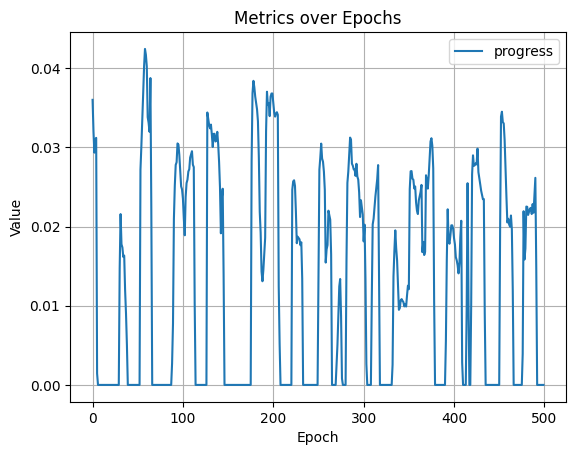

In [4]:
collector.plot(
    "progress",
)

In [5]:
metrics = result.metrics()
df = metrics.to_polars()
df

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,version,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""selector.roulette""",20.0,10000.0,20.0,0.0,0.0,0.0,20.0,20.0,500,null,null,null,null,null,null,499,1,"[""selector"", ""statistic""]"
"""score.improvement""",1.0,18.0,1.0,0.0,0.0,0.0,1.0,1.0,18,null,null,null,null,null,null,167,1,"[""statistic"", ""score""]"
"""crossover.blend.time""",0.000015,0.008581,0.000017,0.000002,2.7916e-12,0.0,0.000013,0.000033,500,8581µs,17µs,1µs,12µs,32µs,0µs,499,1,"[""alterer"", ""crossover"", ""time""]"
"""age.replace""",1.0,6.0,2.0,1.732051,3.0,9.0,1.0,4.0,3,null,null,null,null,null,null,494,1,"[""failure"", ""age"", ""statistic""]"
"""selector.roulette.time""",0.000004,0.002067,0.000004,4.7128e-7,2.2210e-13,0.0,0.000004,0.000008,500,2066µs,4µs,0µs,3µs,8µs,0µs,499,1,"[""selector"", ""time""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""count.survivor""",17.0,7863.0,15.726,2.105181,4.431787,-1.531058,0.0,20.0,500,null,null,null,null,null,null,499,1,"[""derived"", ""statistic""]"
"""score.volatility""",0.900161,519.700806,1.039402,0.262987,0.069162,0.0,0.427818,2.96543,500,null,null,null,null,null,null,499,1,"[""derived"", ""statistic"", ""score""]"
"""rate.diversity""",0.97,478.850006,0.9577,0.019852,0.000394,0.0,0.9,1.0,500,null,null,null,null,null,null,499,1,"[""derived"", ""statistic"", ""rate""]"


In [6]:
print(result.metrics().dashboard())
# pprint.pprint(metrics["rate.carryover"].tags())

for metric in metrics.values_by_tag(rd.Tag.DERIVED):
    print(metric)

print()
pprint.pprint(metrics["rate.carryover"].to_dict())

[40 metrics, 19022 updates]
----- Metrics ----- (40 :: 19022) 
  carryover: 0.164  diversity: 0.958  unique_members: 97  unique_scores: 97  improvements: 18  iter_time(mean): 851.647µs

== Distributions ==
Name                       | Type   | Mean       | Min        | Max        | N      | Total        | StdDev     | Skew       | Kurt       | Entr      
-------------------------------------------------------------------------------------------------------------------------------------------------
age                        | dist   | 0.470      | 0.000      | 8.000      | 100    | 0.047        | 1.446      | 12.167     | 91.199     | -         
alter.cross_family         | dist   | 43.000     | 43.000     | 43.000     | 1      | 0.043        | 0.000      | NaN        | NaN        | -         
alter.parent_reuse         | dist   | 2.196      | 1.000      | 21.000     | 56     | 0.123        | 3.300      | 5.484      | 32.857     | -         
alter.within_family        | dist   | 123.00

In [7]:
df = collector.to_polars(lazy=False)

df = (
    df.filter(
        (pl.col("update_count") > 1) & (~pl.col("tags").list.contains("distribution"))
    )
    .select("name", "version", "update_count", "tags")
    .group_by("name")
    .agg(
        pl.col("update_count").sum().alias("update_count"),
    )
    .sort("update_count", descending=False)
)

df

name,update_count
str,i64
"""count.evaluation""",2
"""step.evaluate.time""",1000


In [8]:
df = collector.to_polars(lazy=False)

In [9]:
df.filter(pl.col("name") == "gaussian_mutator")

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,version,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
